# Динамическая атрибутированная экономическая сеть МО СЗФО
Воспроизводимый пайплайн анализа экономической структуры 282 МО СЗФО за 2024 год.

In [1]:
!pip install -q python-igraph leidenalg plotly geopandas pyarrow openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from scipy.optimize import linear_sum_assignment
import igraph as ig
import leidenalg as la
import plotly.graph_objects as go
import plotly.io as pio

print("ok")

ok


In [3]:
from pathlib import Path

ROOT = Path("/content")
DATA = ROOT
OUT_FIG = ROOT / "outputs" / "figures"
OUT_TAB = ROOT / "outputs" / "tables"
OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB.mkdir(parents=True, exist_ok=True)

CATEGORIES = ["Маркетплейсы", "Здоровье", "Продовольствие", "Транспорт", "Общественное питание"]
SEASONS = {"Зима": [12, 1, 2], "Весна": [3, 4, 5], "Лето": [6, 7, 8], "Осень": [9, 10, 11]}
SEASON_ORDER = ["Зима", "Весна", "Лето", "Осень"]
KNN_K = 10
LEIDEN_RES = 1.0
LEIDEN_SEED = 42
MIN_MONTHS = 10

PALETTE = [
    "#67001f", "#e66101", "#fdb863", "#b8e186", "#c7eae5",
    "#b2abd2", "#5e3c99", "#9e9e9e", "#5b8fc9", "#c1666b",
]
CRS_ALBERS = "+proj=aea +lat_1=50 +lat_2=70 +lat_0=60 +lon_0=40 +datum=WGS84"

print("DATA =", DATA)
print("файл существует:", (DATA / "data.csv").exists())

DATA = /content
файл существует: True


In [7]:
def norm(s):
    if pd.isna(s): return s
    return re.sub(r"\s+", " ", str(s).replace("\xa0", " ").strip().lower())

# --- данные ---
df = pd.read_csv(DATA / "data.csv", sep=";", encoding="utf-8-sig",
                 dtype={"mobility": float, "salary_rub": int})
df["mo_norm"] = df["mo"].map(norm)

print("df:", df.shape)
print("Колонки:", df.columns.tolist())
print("Уникальных МО:", df["mo"].nunique())
print("mobility:", df["mobility"].min(), "–", df["mobility"].max())
print("salary_rub:", df["salary_rub"].min(), "–", df["salary_rub"].max())

# --- геометрии ---
gdf = gpd.read_file(DATA / "szfo_boundaries.gpkg")
gdf = gdf[gdf["year_to"].astype(str) == "9999"].copy()
gdf = gdf.to_crs(CRS_ALBERS)
gdf["mo_norm"] = gdf["municipal_district_name"].map(norm)

print("\ngdf:", gdf.shape)
print("CRS:", gdf.crs)

df: (17170, 9)
Колонки: ['mo', 'year', 'month', 'category', 'spend', 'share', 'mobility', 'salary_rub', 'mo_norm']
Уникальных МО: 282
mobility: 0.144 – 14.447
salary_rub: 54986 – 135206

gdf: (393, 12)
CRS: +proj=aea +lat_1=50 +lat_2=70 +lat_0=60 +lon_0=40 +datum=WGS84 +type=crs


long: (1116, 9) | МО: 279
seasonal_structure.jpg сохранён


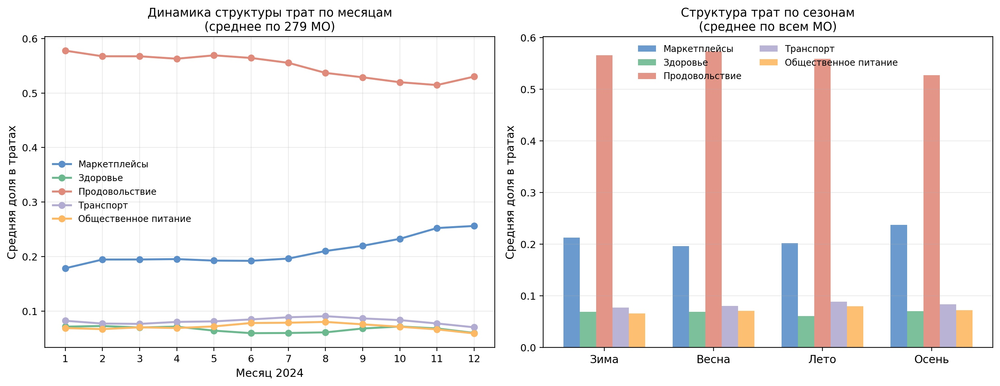

In [9]:
# --- фильтр неполных МО ---
months_per_mo = df.groupby("mo")["month"].nunique()
df_ok = df[df["mo"].isin(months_per_mo[months_per_mo >= MIN_MONTHS].index)].copy()

# --- сезон ---
month2season = {m: s for s, ms in SEASONS.items() for m in ms}
df_ok["season"] = df_ok["month"].map(month2season)

# --- агрегация ---
shares = (df_ok.groupby(["mo", "season", "category"])["share"]
                .mean().unstack("category")
                .reindex(columns=CATEGORIES).reset_index())

mo_attrs = (df_ok.groupby("mo")[["mobility", "salary_rub"]]
                  .first().reset_index())

long = shares.merge(mo_attrs, on="mo", how="left")
long["season"] = pd.Categorical(long["season"], categories=SEASON_ORDER, ordered=True)
long = long.sort_values(["mo", "season"]).reset_index(drop=True)

print("long:", long.shape, "| МО:", long["mo"].nunique())

# =================== ВИЗУАЛИЗАЦИЯ ===================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- 1. Динамика долей трат по месяцам (среднее по всем МО) ---
monthly = (df_ok.groupby(["month", "category"])["share"]
                .mean().unstack("category").reindex(columns=CATEGORIES))

ax = axes[0]
colors_cat = {"Маркетплейсы":"#5b8fc9","Здоровье":"#6db98f",
              "Продовольствие":"#e08a7b","Транспорт":"#b2abd2",
              "Общественное питание":"#fdb863"}
for cat in CATEGORIES:
    ax.plot(monthly.index, monthly[cat], "o-",
            color=colors_cat[cat], label=cat, linewidth=2, markersize=6)
ax.set_xlabel("Месяц 2024", fontsize=11)
ax.set_ylabel("Средняя доля в тратах", fontsize=11)
ax.set_title("Динамика структуры трат по месяцам\n(среднее по 279 МО)", fontsize=12)
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.25)
ax.legend(fontsize=9, frameon=False)

# --- 2. Столбики: доли трат по сезонам (среднее по всем МО) ---
seasonal = long.groupby("season", observed=True)[CATEGORIES].mean()
x = np.arange(len(SEASON_ORDER))
width = 0.15
ax = axes[1]
for i, cat in enumerate(CATEGORIES):
    ax.bar(x + (i - 2) * width, seasonal[cat], width,
           color=colors_cat[cat], label=cat, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(SEASON_ORDER, fontsize=11)
ax.set_ylabel("Средняя доля в тратах", fontsize=11)
ax.set_title("Структура трат по сезонам\n(среднее по всем МО)", fontsize=12)
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=9, frameon=False, ncol=2)

plt.tight_layout()
plt.savefig(OUT_FIG / "seasonal_structure.jpg", dpi=220, bbox_inches="tight",
            facecolor="white", pil_kwargs={"quality": 95, "optimize": True})
plt.close()
print("seasonal_structure.jpg сохранён")

# показать
from IPython.display import Image, display
display(Image("/content/outputs/figures/seasonal_structure.jpg"))

explained variance: [0.646 0.127 0.076]
сумма: 0.849
pca_triptych.jpg сохранён


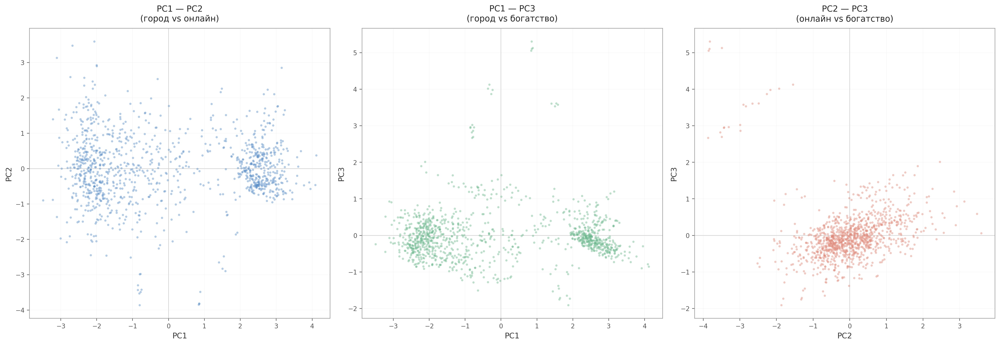

In [10]:
import matplotlib.pyplot as plt
import numpy as np

FEATS = CATEGORIES + ["mobility", "salary_rub"]
X = long[FEATS].values

scaler = StandardScaler()
Xs = scaler.fit_transform(X)
pca = PCA(n_components=3, random_state=42)
Z = pca.fit_transform(Xs)

long["pc1"], long["pc2"], long["pc3"] = Z[:, 0], Z[:, 1], Z[:, 2]

print("explained variance:", pca.explained_variance_ratio_.round(3))
print("сумма:", pca.explained_variance_ratio_.sum().round(3))

# =================== ТРИПТИХ ===================
pairs = [
    ("pc1", "pc2", "PC1 — PC2\n(город vs онлайн)",  "#5b8fc9", "PC1", "PC2"),
    ("pc1", "pc3", "PC1 — PC3\n(город vs богатство)", "#6db98f", "PC1", "PC3"),
    ("pc2", "pc3", "PC2 — PC3\n(онлайн vs богатство)", "#e08a7b", "PC2", "PC3"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (cx, cy, title, color, xlab, ylab) in zip(axes, pairs):
    x = long[cx].values
    y = long[cy].values

    ax.scatter(x, y, s=10, c=color, alpha=0.45,
               edgecolors="none", zorder=2)

    ax.axhline(0, color="#cccccc", linewidth=0.8, zorder=1)
    ax.axvline(0, color="#cccccc", linewidth=0.8, zorder=1)
    ax.grid(alpha=0.25, color="#e0e0e0", linewidth=0.6)

    ax.set_xlabel(xlab, fontsize=11, color="#333333")
    ax.set_ylabel(ylab, fontsize=11, color="#333333")
    ax.set_title(title, fontsize=12, color="#222222", pad=10)

    for spine in ax.spines.values():
        spine.set_color("#999999")
        spine.set_linewidth(0.8)
    ax.tick_params(colors="#555555", labelsize=9)

plt.tight_layout()
plt.savefig(OUT_FIG / "pca_triptych.jpg", dpi=220, bbox_inches="tight",
            facecolor="white", pil_kwargs={"quality": 95, "optimize": True})
plt.close()
print("pca_triptych.jpg сохранён")
from IPython.display import Image, display
display(Image("/content/outputs/figures/pca_triptych.jpg"))

In [11]:
def cluster_slice(Z_slice, k=KNN_K, res=LEIDEN_RES, seed=LEIDEN_SEED):
    A = kneighbors_graph(Z_slice, n_neighbors=k, mode="connectivity", include_self=False)
    A = A.maximum(A.T)
    A_dense = np.asarray(A.todense())
    g = ig.Graph.Adjacency((A_dense > 0).tolist(), mode=ig.ADJ_UNDIRECTED)
    part = la.find_partition(g, la.RBConfigurationVertexPartition,
                             resolution_parameter=res, seed=seed)
    return np.array(part.membership), part.modularity

labels, mods = {}, {}
for s in SEASON_ORDER:
    Zs = long.loc[long.season == s, ["pc1", "pc2", "pc3"]].values
    lab, mod = cluster_slice(Zs)
    labels[s] = lab
    mods[s] = mod
    print(f"{s}: {lab.max()+1} кластеров, модулярность = {mod:.3f}")

Зима: 8 кластеров, модулярность = 0.717
Весна: 8 кластеров, модулярность = 0.706
Лето: 8 кластеров, модулярность = 0.723
Осень: 7 кластеров, модулярность = 0.728


In [12]:
def centroids(Z, lab):
    n = lab.max() + 1
    return np.array([Z[lab == c].mean(axis=0) for c in range(n)])

def align(Z_a, lab_a, Z_b, lab_b):
    Ca, Cb = centroids(Z_a, lab_a), centroids(Z_b, lab_b)
    n = min(len(Ca), len(Cb))
    D = np.linalg.norm(Ca[:n, None, :] - Cb[None, :n, :], axis=2)
    row, col = linear_sum_assignment(D)
    mapping = {int(col[i]): int(row[i]) for i in range(n)}
    return np.array([mapping.get(int(l), -1) for l in lab_b]), mapping

aligned = {"Зима": labels["Зима"]}
for prev, cur in zip(SEASON_ORDER[:-1], SEASON_ORDER[1:]):
    Zp = long.loc[long.season == prev, ["pc1", "pc2", "pc3"]].values
    Zc = long.loc[long.season == cur, ["pc1", "pc2", "pc3"]].values
    lab_al, mapping = align(Zp, aligned[prev], Zc, labels[cur])
    aligned[cur] = lab_al
    sc = float((aligned[prev] != lab_al).mean())
    print(f"{prev} → {cur}: share_changed = {sc:.4f}")

trans = pd.crosstab(pd.Series(aligned["Зима"], name="from"),
                    pd.Series(aligned["Осень"], name="to"))
print("\nМатрица переходов Зима → Осень:")
print(trans)

Зима → Весна: share_changed = 0.2581
Весна → Лето: share_changed = 0.1864
Лето → Осень: share_changed = 0.3082

Матрица переходов Зима → Осень:
to     0   1   2   3   4   5   6
from                            
0     27   0  11   4   0   0   1
1      2  35   0   0   0   0   4
2      0  11  13   0   0   0  15
3      0   0   0  25  11   0   0
4      1   0   0   0  22  12   0
5      0   0   0   0   1  34   0
6      3   1   1   0   0   0  25
7      0   1  18   1   0   0   0


maps_seasons.jpg сохранён


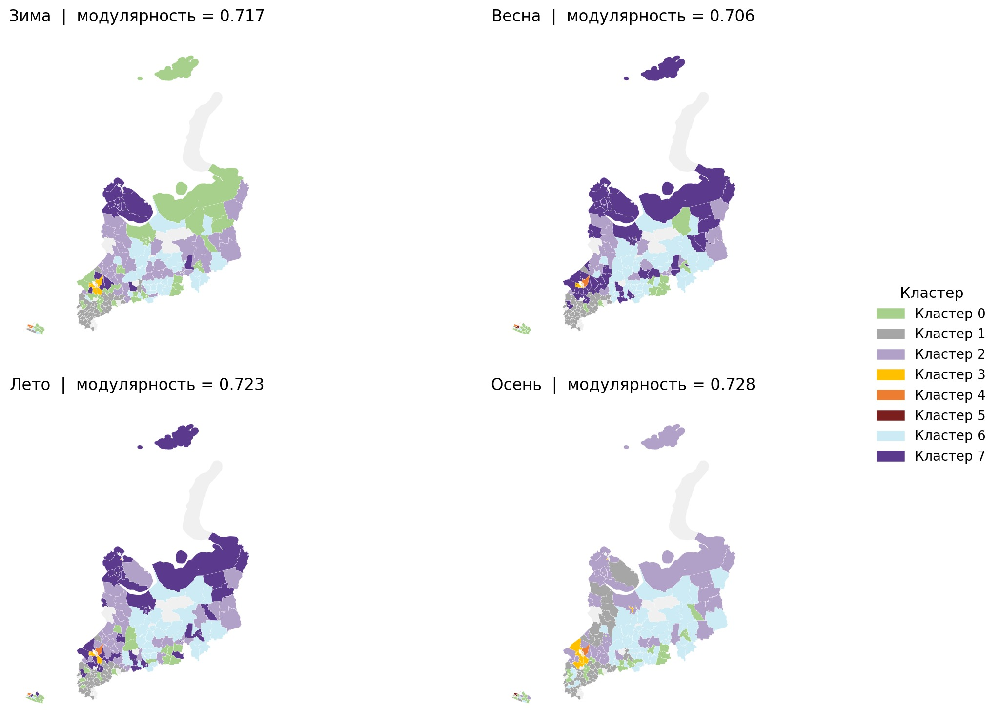

In [17]:
PALETTE_SOFT = [
    "#a8d08d", "#a6a6a6", "#b1a0c7", "#ffc000",
    "#ed7d31", "#7b1e1e", "#ccebf5", "#5b3a8e",
]

import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(right=0.85)

for ax, s in zip(axes.ravel(), SEASON_ORDER):
    lab_map = {norm(mo): int(l) for mo, l in
               zip(long.loc[long.season == s, "mo"], aligned[s])}
    gdf["cluster"] = gdf["mo_norm"].map(lab_map)
    colors = gdf["cluster"].map(
        lambda l: PALETTE_SOFT[int(l) % len(PALETTE_SOFT)]
        if pd.notna(l) else "#f0f0f0")
    gdf.plot(ax=ax, color=colors, edgecolor="white", linewidth=0.1)
    ax.set_title(f"{s}  |  модулярность = {mods[s]:.3f}", fontsize=13)
    ax.axis("off")

handles = [mpatches.Patch(color=PALETTE_SOFT[i], label=f"Кластер {i}")
           for i in range(len(PALETTE_SOFT))]
fig.legend(handles=handles, loc="center right", fontsize=11,
           title="Кластер", title_fontsize=12,
           frameon=False, bbox_to_anchor=(0.99, 0.5))

plt.savefig(OUT_FIG / "maps_seasons.jpg", dpi=180, bbox_inches="tight",
            facecolor="white", pil_kwargs={"quality": 92, "optimize": True})
plt.close()
print("maps_seasons.jpg сохранён")

from IPython.display import Image, display
display(Image("/content/outputs/figures/maps_seasons.jpg", width=900))

In [26]:
import plotly.express as px
import json

gdf_ref = gdf.copy().to_crs(epsg=4326)

fig = px.choropleth_mapbox(
    gdf_ref,
    geojson=json.loads(gdf_ref.to_json()),
    locations=gdf_ref.index,
    color_discrete_sequence=["#e0e0e0"],
    hover_name="municipal_district_name",
    mapbox_style="white-bg",
    center={"lat": 64.0, "lon": 40.0},
    zoom=3.5,
    opacity=0.5,
)

fig.update_traces(
    marker_line_width=0.5,
    marker_line_color="#888888",
)

fig.update_layout(
    margin={"r": 0, "t": 0, "l": 0, "b": 0},
    height=650,
    showlegend=False,
    mapbox=dict(bearing=0, pitch=0),
)

fig.write_html(OUT_FIG / "map_reference.html")
fig.show()

timeline.jpg сохранён


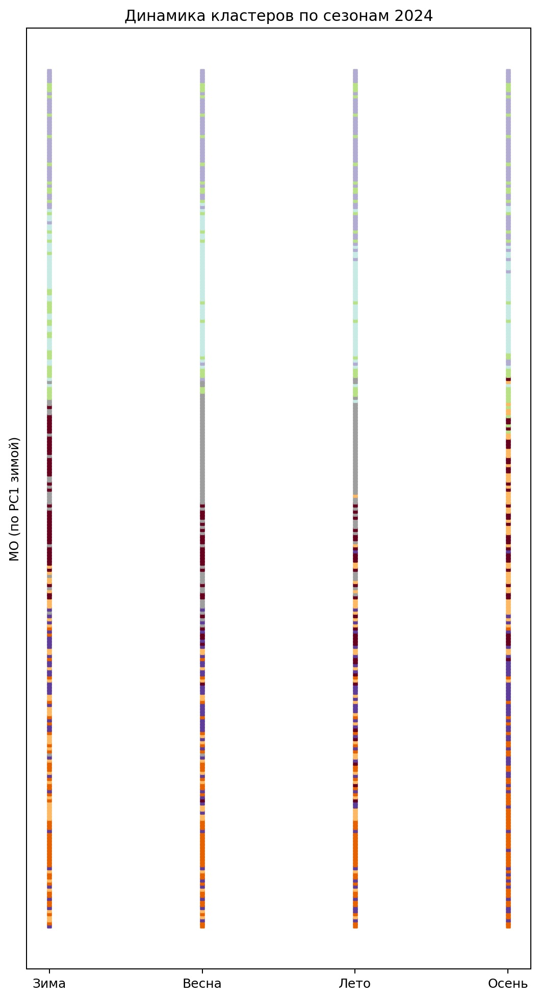

In [29]:
mo_order = (long.loc[long.season == "Зима", ["mo", "pc1"]]
                .sort_values("pc1")["mo"].values)
lab_wide = pd.DataFrame(
    {s: dict(zip(long.loc[long.season == s, "mo"], aligned[s]))
     for s in SEASON_ORDER}
).loc[mo_order]

fig, ax = plt.subplots(figsize=(6, 11))
for j, s in enumerate(SEASON_ORDER):
    colors = [PALETTE[l % len(PALETTE)] if l >= 0 else "#cccccc"
              for l in lab_wide[s]]
    ax.scatter([j] * len(lab_wide), range(len(lab_wide)),
               c=colors, s=8, marker="s")
ax.set_xticks(range(len(SEASON_ORDER)))
ax.set_xticklabels(SEASON_ORDER)
ax.set_yticks([])
ax.set_ylabel("МО (по PC1 зимой)")
ax.set_title("Динамика кластеров по сезонам 2024")
plt.tight_layout()
plt.savefig(OUT_FIG / "timeline.jpg", dpi=180, bbox_inches="tight",
            facecolor="white", pil_kwargs={"quality": 92, "optimize": True})
plt.close()
print("timeline.jpg сохранён")

display(Image("/content/outputs/figures/timeline.jpg", width=500))

In [39]:
import plotly.graph_objects as go

PALETTE_TIMELINE = [
    "#a8d08d", "#a6a6a6", "#b1a0c7", "#ffc000",
    "#ed7d31", "#7b1e1e", "#ccebf5", "#5b3a8e",
]

mo_winter = dict(zip(long.loc[long.season == "Зима", "mo"], aligned["Зима"]))

clusters = {}
for mo, c in mo_winter.items():
    if c < 0:
        continue
    clusters.setdefault(int(c), []).append(mo)

ordered_mo = []
cluster_blocks = {}
for c in sorted(clusters.keys()):
    start = len(ordered_mo)
    ordered_mo.extend(sorted(clusters[c]))
    end = len(ordered_mo)
    cluster_blocks[c] = (start, end)

lab_wide = pd.DataFrame(
    {s: dict(zip(long.loc[long.season == s, "mo"], aligned[s]))
     for s in SEASON_ORDER}
).loc[ordered_mo]

X_POSITIONS = [0, 0.35, 0.7, 1.05]
MARKER_SIZE = 18
n_mo = len(ordered_mo)

fig = go.Figure()

for j, s in enumerate(SEASON_ORDER):
    xs, ys, colors, texts = [], [], [], []
    for i, mo in enumerate(lab_wide.index):
        l = lab_wide[s].iloc[i]
        xs.append(X_POSITIONS[j])
        ys.append(i)
        colors.append(PALETTE_TIMELINE[int(l) % len(PALETTE_TIMELINE)]
                      if l >= 0 else "#dddddd")
        texts.append(f"<b>{mo}</b><br>Сезон: {s}<br>Кластер {int(l) if l >= 0 else '—'}")

    fig.add_trace(go.Scatter(
        x=xs, y=ys,
        mode="markers",
        marker=dict(color=colors, size=MARKER_SIZE, symbol="square"),
        text=texts,
        hoverinfo="text",
        showlegend=False,
    ))

for c, (start, end) in cluster_blocks.items():
    y_mid = (start + end - 1) / 2
    fig.add_annotation(
        x=1.6, y=y_mid,
        xref="x", yref="y",
        text=f"Кластер {c} ({end - start} МО)",
        showarrow=False,
        align="left",
        font=dict(size=13),
        xanchor="left",
    )
    if start > 0:
        fig.add_shape(
            type="line",
            x0=-0.25, x1=1.35, y0=start - 0.5, y1=start - 0.5,
            line=dict(color="#bbbbbb", width=1),
        )

for c in sorted(clusters.keys()):
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode="markers",
        marker=dict(color=PALETTE_TIMELINE[c], size=16, symbol="square"),
        name=f"Кластер {c}",
        showlegend=True,
        hoverinfo="skip",
    ))

fig.update_layout(
    title=dict(
        text="Динамика кластеров МО СЗФО по сезонам 2024",
        x=0.5, xanchor="center", font=dict(size=20),
    ),
    xaxis=dict(
        tickmode="array",
        tickvals=X_POSITIONS,
        ticktext=SEASON_ORDER,
        showgrid=False,
        range=[-0.25, 3.5],
        title=dict(text="Кластер (Зима)", font=dict(size=13)),
        tickfont=dict(size=14),
    ),
    yaxis=dict(
        showticklabels=False,
        showgrid=False,
        range=[-1, n_mo],
        title="",
    ),
    height=900,
    margin={"r": 20, "t": 70, "l": 30, "b": 160},
    plot_bgcolor="white",
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.10,
        xanchor="center",
        x=0.5,
        font=dict(size=13),
        bgcolor="rgba(0,0,0,0)",
    ),
)

fig.write_html(OUT_FIG / "timeline_interactive.html")
fig.show()

In [30]:
import plotly.graph_objects as go
import plotly.io as pio

labels_wide = pd.DataFrame({
    "mo": long.loc[long.season == "Зима", "mo"].values,
    **{s: aligned[s] for s in SEASON_ORDER},
})

nodes, node_index = [], {}
for s_i, s in enumerate(SEASON_ORDER):
    for cl in sorted(labels_wide[s].unique()):
        node_index[(s_i, cl)] = len(nodes)
        nodes.append({
            "label": f"Кластер {cl}",
            "color": PALETTE[int(cl) % len(PALETTE)],
        })

sources, targets, values, link_colors = [], [], [], []
for s_i in range(len(SEASON_ORDER) - 1):
    cross = pd.crosstab(labels_wide[SEASON_ORDER[s_i]],
                        labels_wide[SEASON_ORDER[s_i+1]])
    for cl_from in cross.index:
        for cl_to in cross.columns:
            v = cross.loc[cl_from, cl_to]
            if v > 0:
                sources.append(node_index[(s_i, int(cl_from))])
                targets.append(node_index[(s_i+1, int(cl_to))])
                values.append(int(v))
                h = PALETTE[int(cl_from) % len(PALETTE)].lstrip("#")
                r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
                link_colors.append(f"rgba({r},{g},{b},0.4)")

fig_sankey = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20, thickness=22,
        line=dict(color="white", width=0.8),
        label=[n["label"] for n in nodes],
        color=[n["color"] for n in nodes],
    ),
    link=dict(source=sources, target=targets, value=values, color=link_colors),
    arrangement="snap")])

fig_sankey.update_layout(
    title="Динамика кластеров по сезонам 2024",
    font=dict(size=11), height=750, width=1400,
    plot_bgcolor="white", paper_bgcolor="white")

pio.write_html(fig_sankey, OUT_FIG / "sankey_seasons.html",
               include_plotlyjs="cdn", full_html=True)
print("sankey_seasons.html сохранён")
fig_sankey.show()

sankey_seasons.html сохранён


In [38]:
pd.DataFrame({
    "mo": long.loc[long.season == "Зима", "mo"].values,
    **{s: aligned[s] for s in SEASON_ORDER},
}).to_csv(OUT_TAB / "seasonal_labels.csv",
          index=False, sep=";", encoding="utf-8-sig")

trans.to_csv(OUT_TAB / "transition_matrix.csv",
             sep=";", encoding="utf-8-sig")

pd.DataFrame({"season": SEASON_ORDER,
              "modularity": [mods[s] for s in SEASON_ORDER]}).to_csv(
    OUT_TAB / "modularity_by_season.csv",
    index=False, sep=";", encoding="utf-8-sig")

long.to_parquet(OUT_TAB / "long_with_pca.parquet", index=False)

print("Все результаты сохранены:")
print("- Картинки:", OUT_FIG)
print("- Таблицы:", OUT_TAB)

Все результаты сохранены:
- Картинки: /content/outputs/figures
- Таблицы: /content/outputs/tables
